### Read the SNOWPACK MLD4 & TKG4 WY2020-WY2025 Simulations, SWE Figures

created by Cassie Lumbrazo\
last updated: June 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/mld4'

## Put Some JIF Data info a simple dataframe to plot later (SWE this time)

In [14]:
# SWE DATAFRAMES
df_field_swe_tkg4 = pd.DataFrame({
    'date': ['2024-06-07', '2024-06-15'],
    'site': ['tkg4', 'tkg4'],
    'swe_cm': [313, 343],
    # convert to mm 
    'swe_mm': [3130, 3430],
})

df_field_swe_tkg4['date'] = pd.to_datetime(df_field_swe_tkg4['date'])
df_field_swe_tkg4

df_field_swe_mld4 = pd.DataFrame({
    'date': ['2024-06-11', '2024-06-18'],
    'site': ['mld4', 'mld4'],
    'swe_cm': [299, 313],
    'swe_mm': [2990, 3130],
})

df_field_swe_mld4['date'] = pd.to_datetime(df_field_swe_mld4['date'])
df_field_swe_mld4


,date,site,swe_cm,swe_mm
0,2024-06-11,mld4,299,2990
1,2024-06-18,mld4,313,3130


In [30]:
# SNOW DEPTH DATAFRAMES
df_field_depth_tkg4 = pd.DataFrame({
    'date': ['2024-06-15'],
    'site': ['tkg4'],
    'core_depth_cm': [642.5], # this was 800, but it got confusing with the code below, so keeping it the core depth meaning snow-firn transition depth
    # 'snow_firm_transition_depth_cm': [642.5]
})

df_field_depth_tkg4['date'] = pd.to_datetime(df_field_depth_tkg4['date'])
df_field_depth_tkg4


df_field_depth_mld4 = pd.DataFrame({
    'date': ['2024-06-11', '2024-06-18'],
    'site': ['mld4', 'mld4'],
    'core_depth_cm': [678.5, 657]
})

df_field_depth_mld4['date'] = pd.to_datetime(df_field_depth_mld4['date'])
df_field_depth_mld4

,date,site,core_depth_cm
0,2024-06-11,mld4,678.5
1,2024-06-18,mld4,657.0


# Open Data and Model Simulations

## Function for Reading SMET Files 

In [6]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

## Open SNOWPACK SMet Output for WY2020-WY2025

In [7]:
ds_snowpack_mld4, header = read_smet("/home/cassie/python/models/run_snowpack/sites/mld4/output/hrrrak_mld4_WY2020-WY2025_heatflux_soiltemp_zero.smet")
ds_snowpack_tkg4, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tkg4/output/hrrrak_tkg4_WY2020-WY2025_heatflux_soiltemp_zero.smet")

/tmp/ipykernel_235389/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_235389/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Text(0, 0.5, 'snow depth (cm)')

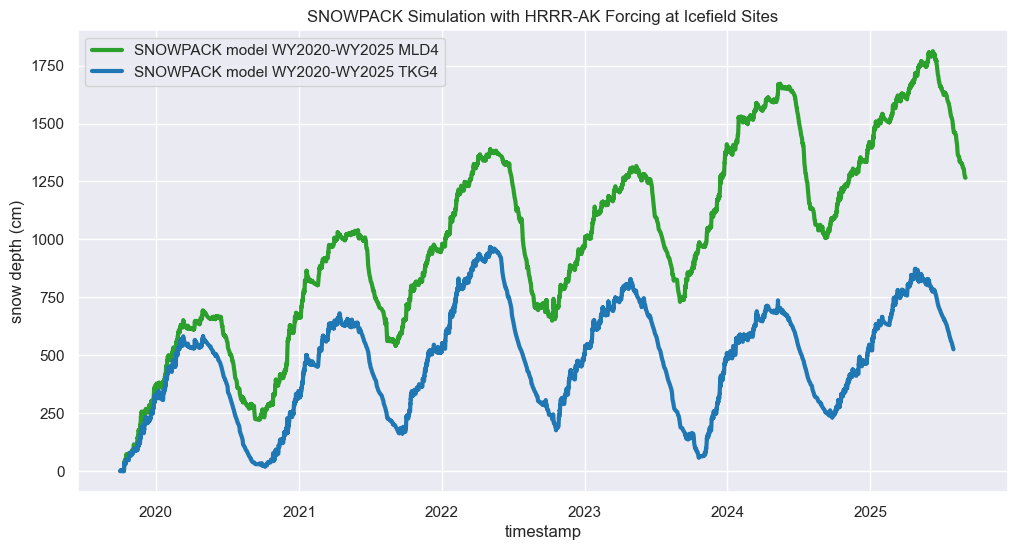

In [12]:
ds_snowpack_mld4.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025 MLD4', linewidth = 3, color='tab:green')
ds_snowpack_tkg4.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025 TKG4', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at Icefield Sites')
plt.legend()

plt.ylabel('snow depth (cm)')

Text(0, 0.5, 'snow depth (cm)')

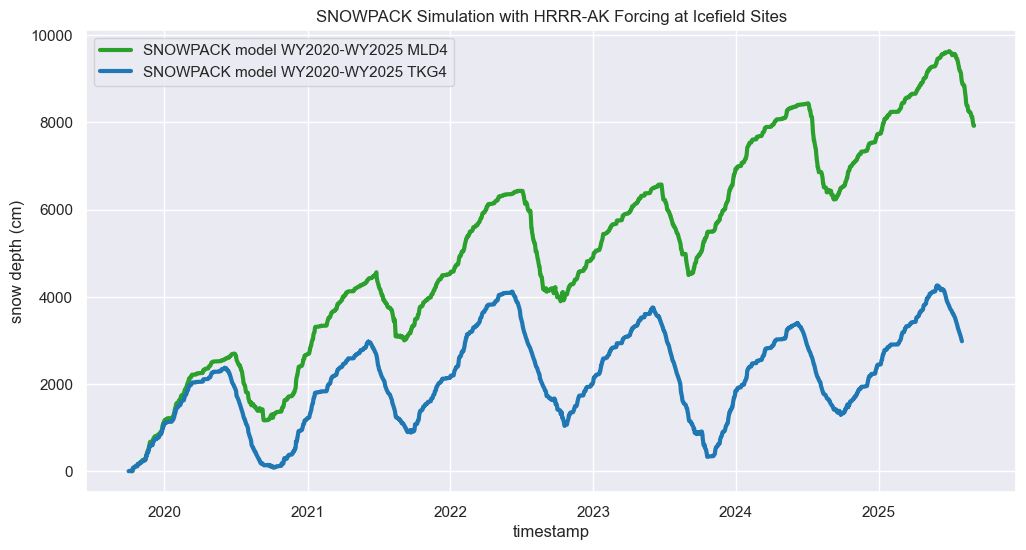

In [13]:
ds_snowpack_mld4.SWE.plot(label = 'SNOWPACK model WY2020-WY2025 MLD4', linewidth = 3, color='tab:green')
ds_snowpack_tkg4.SWE.plot(label = 'SNOWPACK model WY2020-WY2025 TKG4', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at Icefield Sites')
plt.legend()

plt.ylabel('snow depth (cm)')

In [13]:
# what is the modeled snow depth on June 15, 2024 in each simulation?
snow_depth_on_ob1 = ds_snowpack.HS_mod.sel(timestamp=df_field_mld4['date'].iloc[0], method='nearest').values
snow_depth_on_ob2 = ds_snowpack.HS_mod.sel(timestamp=df_field_mld4['date'].iloc[1], method='nearest').values

# print the value for the snow depth on observation date 
print(f"Modeled snow depth on obs1: {snow_depth_on_ob1:.2f} cm")
print(f"Modeled snow depth on obs2: {snow_depth_on_ob2:.2f} cm")

# print the value for the firn-snow transiation depth on June 15, 2024 in df_field_mld4
print(f"Field observation of snow-firm transition depth on obs1: {df_field_mld4['core_depth_cm'].iloc[0]:.2f} cm")
print(f"Field observation of snow-firm transition depth on obs2: {df_field_mld4['core_depth_cm'].iloc[1]:.2f} cm")

Modeled snow depth on obs1: 1641.72 cm
Modeled snow depth on obs2: 1630.70 cm
Field observation of snow-firm transition depth on obs1: 678.50 cm
Field observation of snow-firm transition depth on obs2: 657.00 cm


# Remove the lead up to WY2024

Text(0.5, 1.0, 'SNOWPACK Simulation with HRRR-AK Forcing at MLD4 Site')

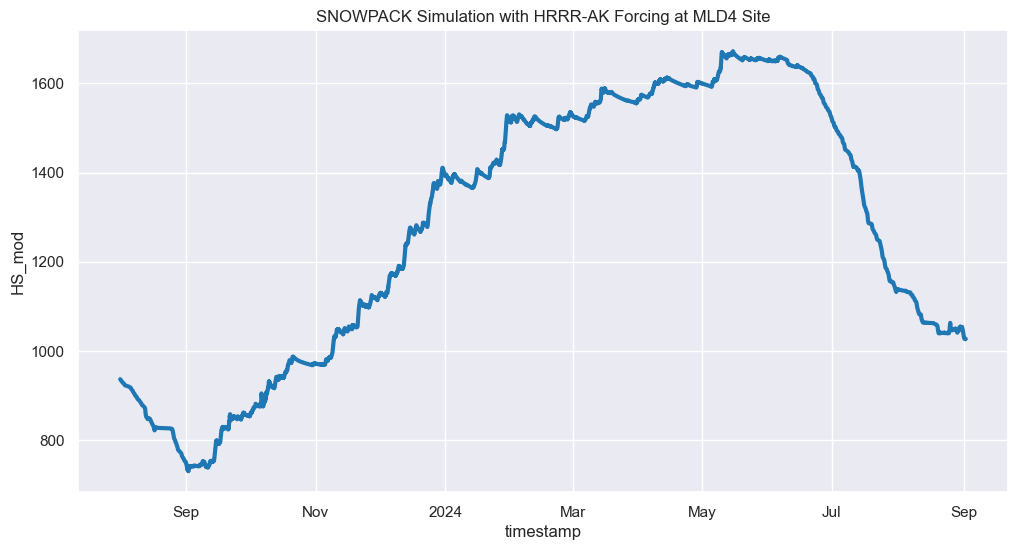

In [14]:
# we want to focus on WY2024
# so let's remove all the data before 

hs_model_ds = ds_snowpack.HS_mod.copy(deep=True)
# now, only keep the dates between 2023-09-01 and 2024-09-01
hs_model_ds = hs_model_ds.sel(timestamp=slice('2023-08-01', '2024-09-01'))
hs_model_ds.plot(label = 'SNOWPACK model WY2024', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at MLD4 Site')

In [15]:
# print the minimum value in the timeseries 
print(f"Minimum snow depth in WY2024: {hs_model_ds.min().values:.2f} cm")


Minimum snow depth in WY2024: 730.36 cm


Text(0.5, 1.0, 'SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

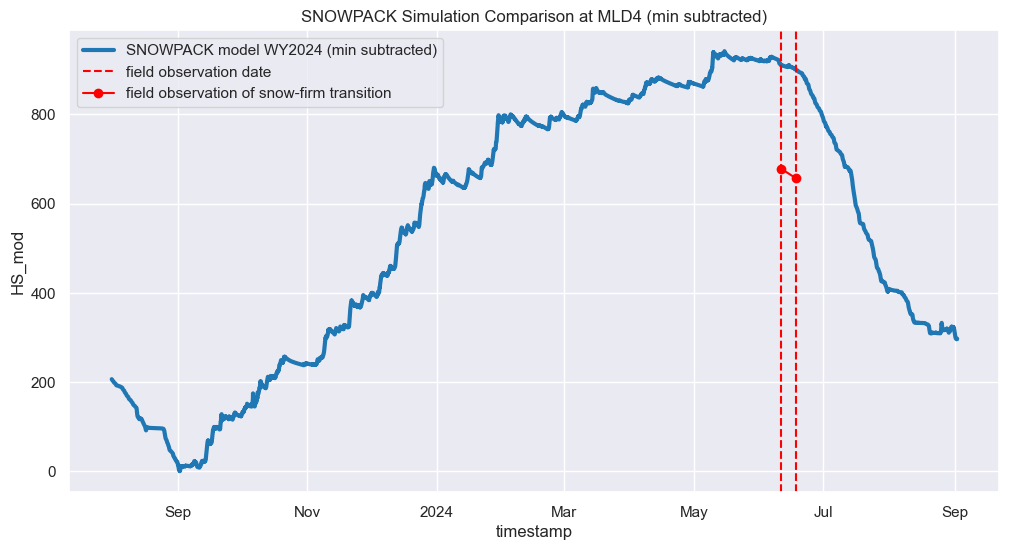

In [16]:
# now, subtract the entire dataset from the minimum value in the dataset 
hs_model_ds = hs_model_ds - hs_model_ds.min()
hs_model_ds.plot(label = 'SNOWPACK model WY2024 (min subtracted)', linewidth = 3, color='tab:blue')

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
plt.legend()
plt.title('SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

Text(0, 0.5, 'snow depth (cm)')

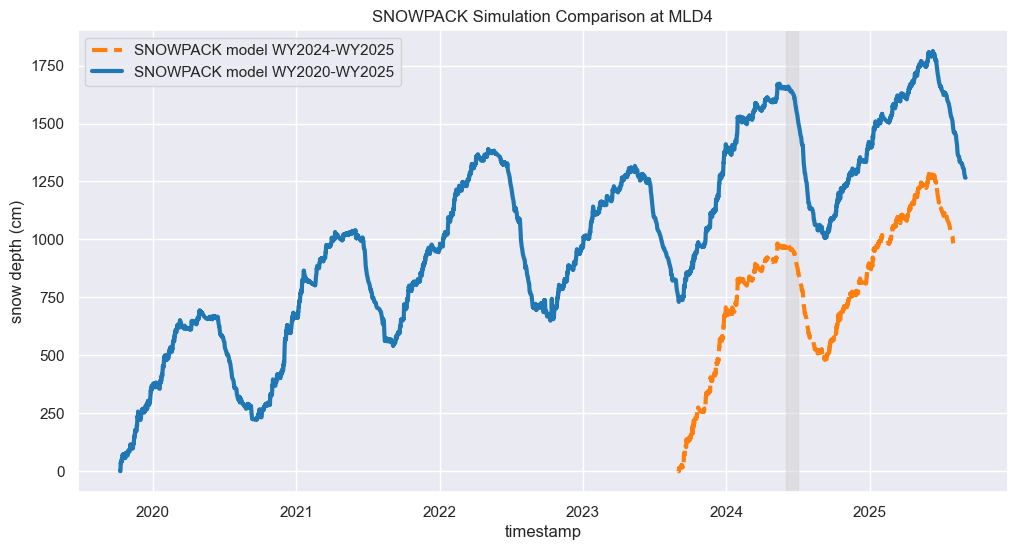

In [19]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')
ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
# plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
# plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
# plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
# plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm_fixed'], marker='o', color='red', label='field observation of snow-firm transition')

plt.title('SNOWPACK Simulation Comparison at MLD4')

# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1])
plt.ylabel('snow depth (cm)')


In [20]:
# cut ds_snowpack_WY2024 to 2024-09-01
ds_snowpack_WY2024_cut = ds_snowpack_WY2024.sel(timestamp=slice('2023-08-01', '2024-09-01'))

Text(0.5, 1.0, 'SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

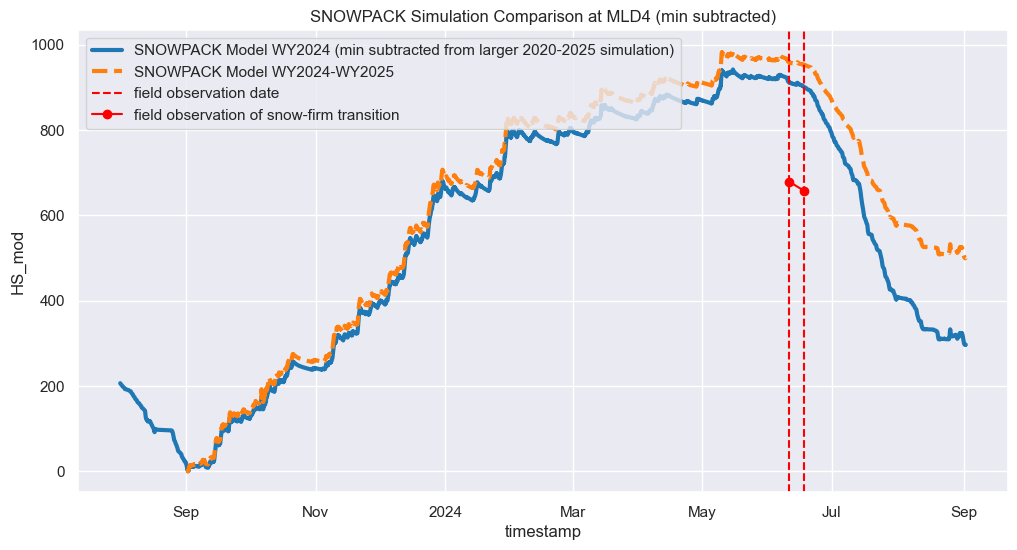

In [21]:
# now, subtract the entire dataset from the minimum value in the dataset 
hs_model_ds = hs_model_ds - hs_model_ds.min()
hs_model_ds.plot(label = 'SNOWPACK Model WY2024 (min subtracted from larger 2020-2025 simulation)', linewidth = 3, color='tab:blue')
# ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')
ds_snowpack_WY2024_cut.HS_mod.plot(label = 'SNOWPACK Model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
plt.legend(loc='upper left')
plt.title('SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

# Deliverable Figures

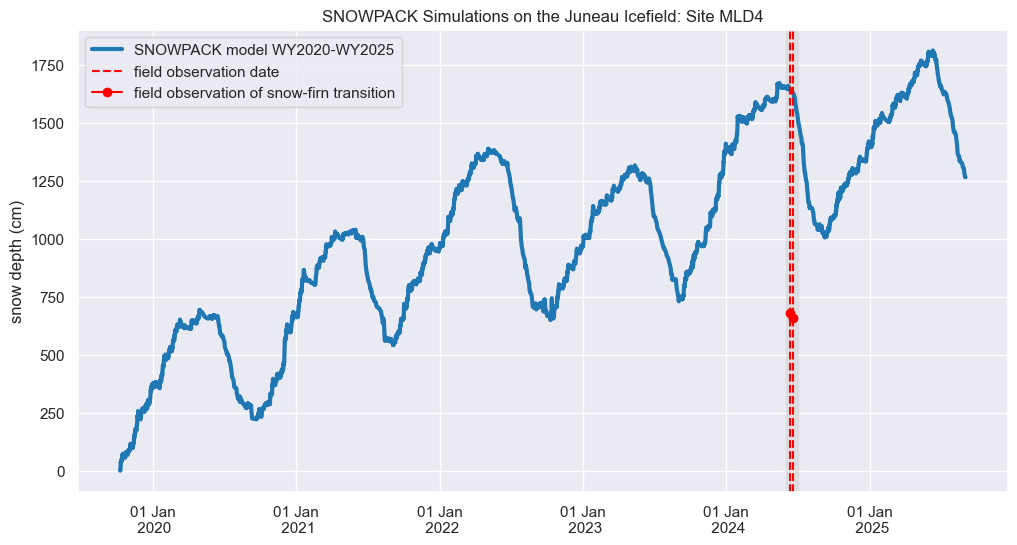

In [22]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
# plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firn transition')
plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firn transition')


# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::1], labels[::1])


plt.title('SNOWPACK Simulations on the Juneau Icefield: Site MLD4')
# add month into the x-axis
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))   
plt.xlabel('')
plt.ylabel('snow depth (cm)')
plt.show()

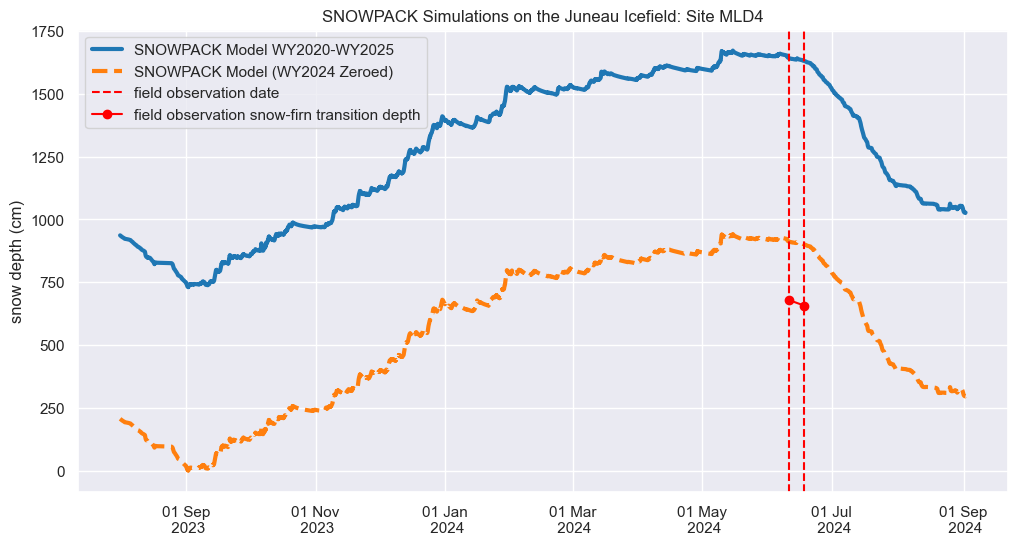

In [24]:
# we want to focus on WY2024
# so let's remove all the data before 

hs_model_ds = ds_snowpack.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_ds.plot(label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

# plot a zeroed-out WY2024 line so the minimum snow depth starts at zero
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')
hs_model_zeroed.plot(label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

# add vertical lines at the field observation dates
plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df core depth 
plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation snow-firn transition depth')

plt.legend(loc='upper left')

plt.title('SNOWPACK Simulations on the Juneau Icefield: Site MLD4')
# add month into the x-axis
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))   
plt.xlabel('')
plt.ylabel('snow depth (cm)')
plt.show()

## Subplot with snow depth and swe together

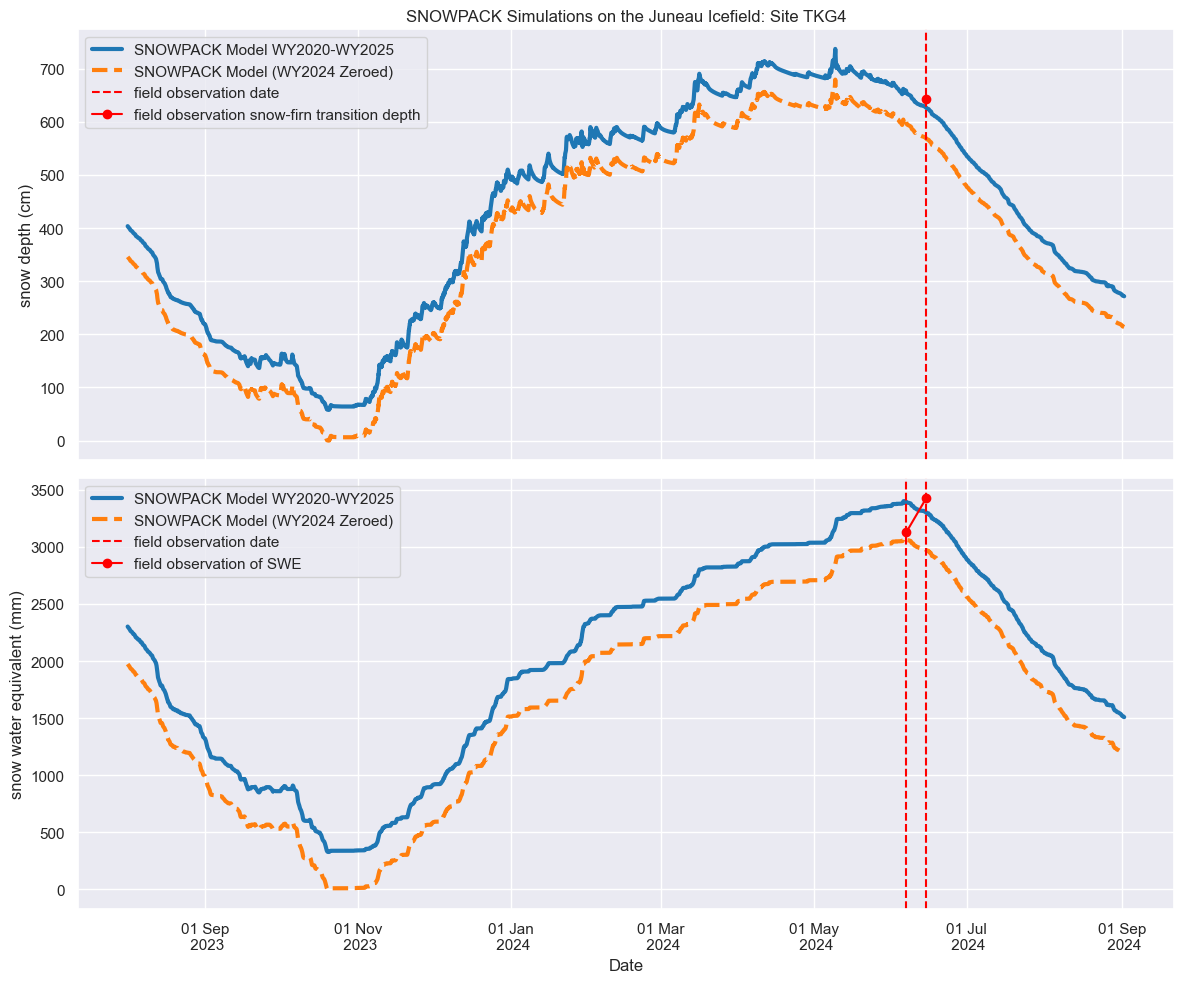

In [31]:
# combined subplot of snow depth and SWE for WY2024
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# top: snow depth
hs_model_ds = ds_snowpack_tkg4.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_ds.plot(ax=axes[0], label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')
hs_model_zeroed.plot(ax=axes[0], label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

axes[0].axvline(df_field_depth_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
# axes[0].axvline(df_field_depth_tkg4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[0].plot(df_field_depth_tkg4['date'], df_field_depth_tkg4['core_depth_cm'], marker='o', color='red', label='field observation snow-firn transition depth')

axes[0].legend(loc='upper left')
axes[0].set_title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')
axes[0].set_xlabel('')
axes[0].set_ylabel('snow depth (cm)')
axes[0].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))

# bottom: SWE
swe_model_ds = ds_snowpack_tkg4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_model_ds.plot(ax=axes[1], label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

swe_model_zeroed = swe_model_ds - swe_model_ds.min(dim='timestamp')
swe_model_zeroed.plot(ax=axes[1], label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

# now add the SWE observations from df_field_swe_tkg4
axes[1].axvline(df_field_swe_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[1].axvline(df_field_swe_tkg4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[1].plot(df_field_swe_tkg4['date'], df_field_swe_tkg4['swe_mm'], marker='o', color='red', label='field observation of SWE')


axes[1].legend(loc='upper left')
# axes[1].set_title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')
axes[1].set_ylabel('snow water equivalent (mm)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))
for label in axes[1].get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')

plt.tight_layout()
plt.show()

# Plot TKG4 and MLD4 Together 

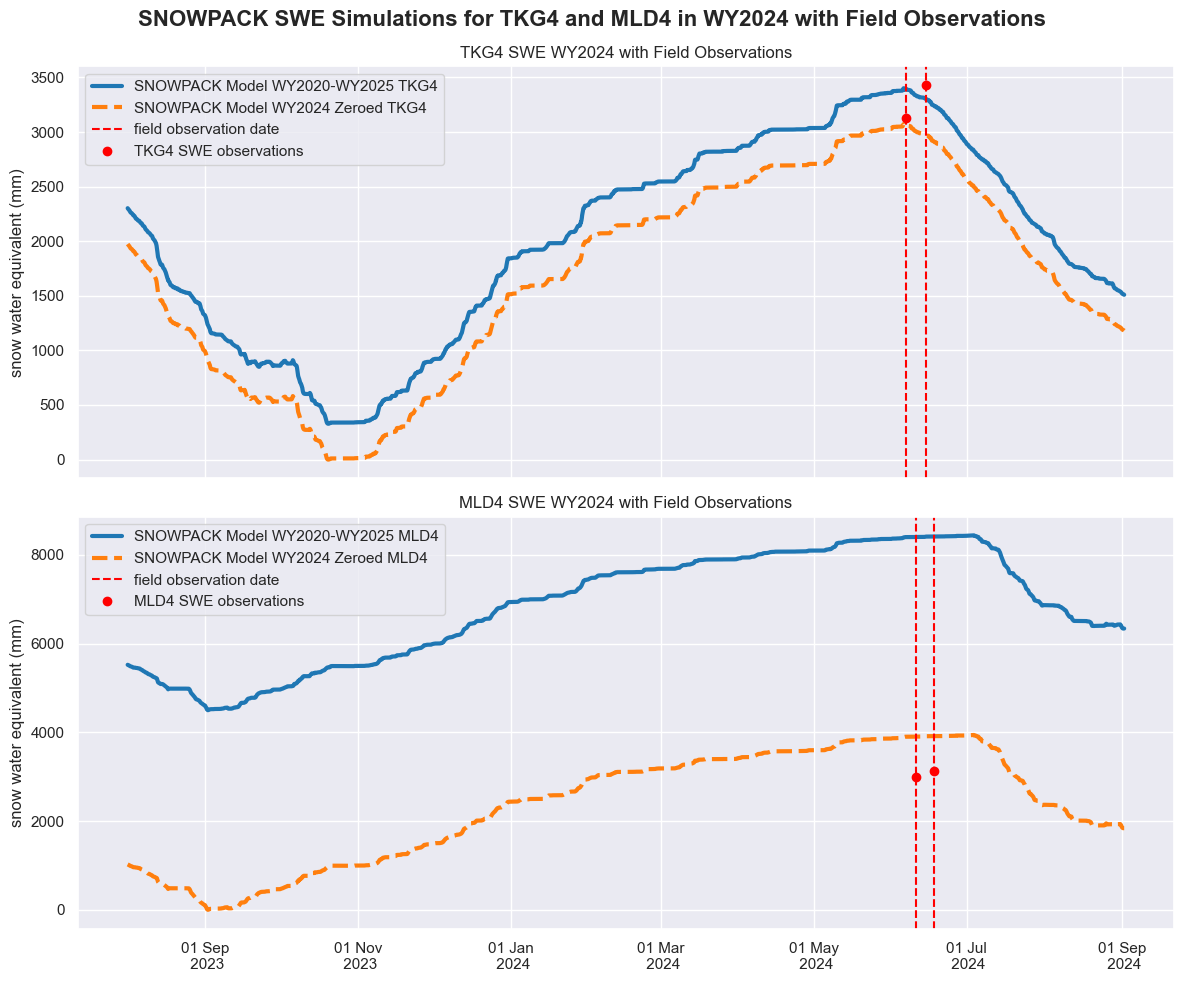

In [41]:
# combined subplot of SWE for TKG4 (top) and MLD4 (bottom) for WY2024
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# top: TKG4 SWE
swe_tkg4 = ds_snowpack_tkg4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_tkg4.plot(ax=axes[0], label='SNOWPACK Model WY2020-WY2025 TKG4', linewidth=3, color='tab:blue')

swe_tkg4_zeroed = swe_tkg4 - swe_tkg4.min(dim='timestamp')
swe_tkg4_zeroed.plot(ax=axes[0], label='SNOWPACK Model WY2024 Zeroed TKG4', linewidth=3, color='tab:orange', linestyle='--')

axes[0].axvline(df_field_swe_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[0].axvline(df_field_swe_tkg4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[0].plot(df_field_swe_tkg4['date'], df_field_swe_tkg4['swe_mm'], marker='o', color='red', linestyle='', label='TKG4 SWE observations')

axes[0].legend(loc='upper left')
axes[0].set_title('TKG4 SWE WY2024 with Field Observations')
axes[0].set_ylabel('snow water equivalent (mm)')
axes[0].set_xlabel('')
axes[0].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))

# bottom: MLD4 SWE
swe_mld4 = ds_snowpack_mld4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_mld4.plot(ax=axes[1], label='SNOWPACK Model WY2020-WY2025 MLD4', linewidth=3, color='tab:blue')

swe_mld4_zeroed = swe_mld4 - swe_mld4.min(dim='timestamp')
swe_mld4_zeroed.plot(ax=axes[1], label='SNOWPACK Model WY2024 Zeroed MLD4', linewidth=3, color='tab:orange', linestyle='--')

axes[1].axvline(df_field_swe_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[1].axvline(df_field_swe_mld4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[1].plot(df_field_swe_mld4['date'], df_field_swe_mld4['swe_mm'], marker='o', color='red', linestyle='', label='MLD4 SWE observations')

axes[1].legend(loc='upper left')
axes[1].set_title('MLD4 SWE WY2024 with Field Observations')
axes[1].set_ylabel('snow water equivalent (mm)')
axes[1].set_xlabel('')
axes[1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))
for label in axes[1].get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')
    
plt.suptitle('SNOWPACK SWE Simulations for TKG4 and MLD4 in WY2024 with Field Observations', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


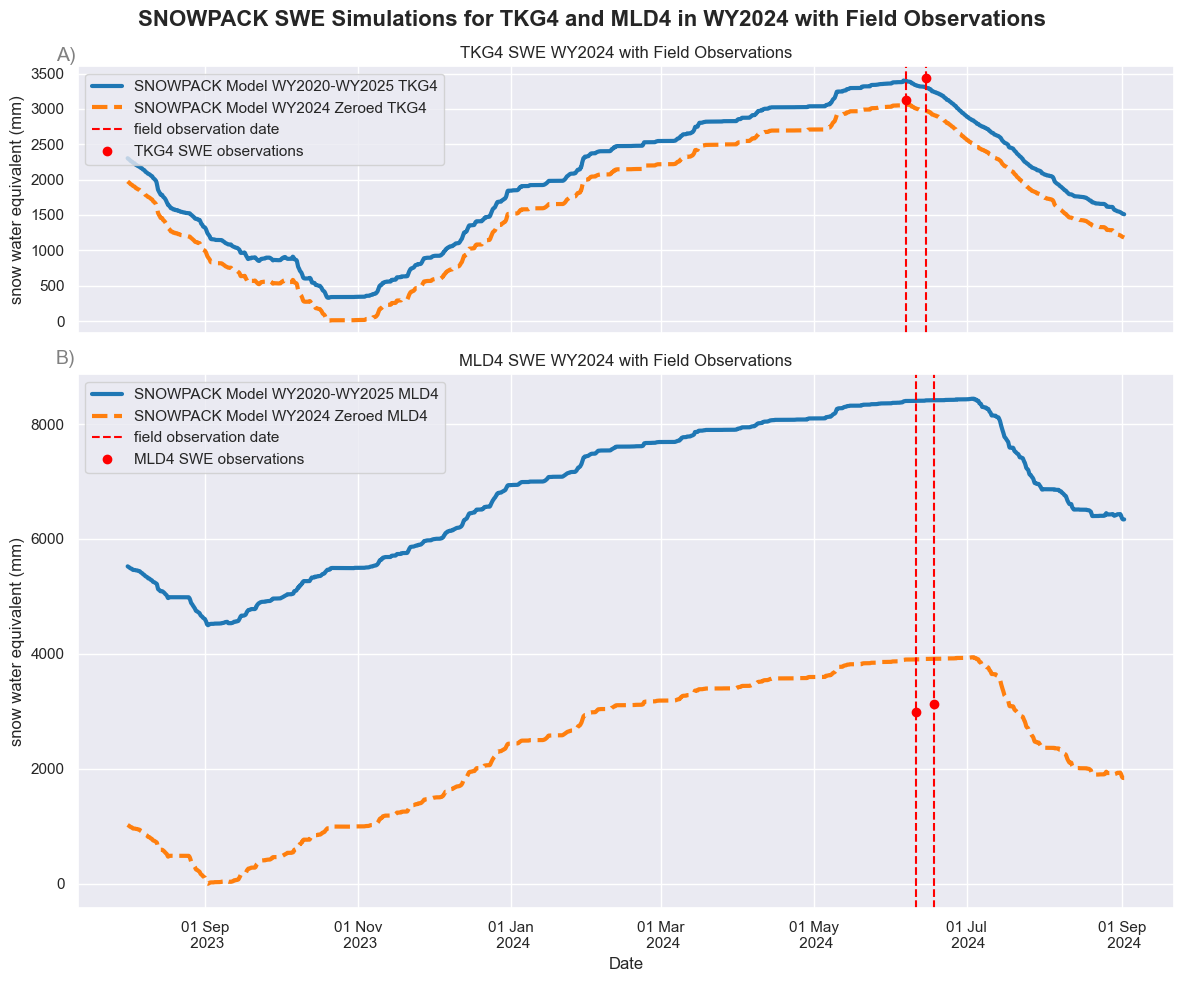

In [53]:
# combined subplot of SWE for TKG4 (top) and MLD4 (bottom) for WY2024
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

# top: TKG4 SWE
swe_tkg4 = ds_snowpack_tkg4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_tkg4.plot(ax=axes[0], label='SNOWPACK Model WY2020-WY2025 TKG4', linewidth=3, color='tab:blue')

swe_tkg4_zeroed = swe_tkg4 - swe_tkg4.min(dim='timestamp')
swe_tkg4_zeroed.plot(ax=axes[0], label='SNOWPACK Model WY2024 Zeroed TKG4', linewidth=3, color='tab:orange', linestyle='--')

axes[0].axvline(df_field_swe_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[0].axvline(df_field_swe_tkg4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[0].plot(df_field_swe_tkg4['date'], df_field_swe_tkg4['swe_mm'], marker='o', color='red', linestyle='', label='TKG4 SWE observations')

axes[0].legend(loc='upper left')
axes[0].set_title('TKG4 SWE WY2024 with Field Observations')
axes[0].set_ylabel('snow water equivalent (mm)')
axes[0].set_xlabel('')
axes[0].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))

# bottom: MLD4 SWE
swe_mld4 = ds_snowpack_mld4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_mld4.plot(ax=axes[1], label='SNOWPACK Model WY2020-WY2025 MLD4', linewidth=3, color='tab:blue')

swe_mld4_zeroed = swe_mld4 - swe_mld4.min(dim='timestamp')
swe_mld4_zeroed.plot(ax=axes[1], label='SNOWPACK Model WY2024 Zeroed MLD4', linewidth=3, color='tab:orange', linestyle='--')

axes[1].axvline(df_field_swe_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[1].axvline(df_field_swe_mld4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[1].plot(df_field_swe_mld4['date'], df_field_swe_mld4['swe_mm'], marker='o', color='red', linestyle='', label='MLD4 SWE observations')

# highlight the MLD4 axes[1] region covered by the TKG4 SWE top plot
# y0_min, y0_max = axes[0].get_ylim()
# axes[1].axhspan(y0_min, y0_max, color='grey', alpha=0.5)

axes[1].legend(loc='upper left')
axes[1].set_title('MLD4 SWE WY2024 with Field Observations')
axes[1].set_ylabel('snow water equivalent (mm)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))
for label in axes[1].get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')
    
# add an A) and B) label to the top left of each subplot
axes[0].text(-0.02, 1.02, 'A)', transform=axes[0].transAxes, color = 'grey', fontsize=14) #, fontweight='bold')
axes[1].text(-0.02, 1.02, 'B)', transform=axes[1].transAxes, color = 'grey', fontsize=14) #, fontweight='bold')

plt.suptitle('SNOWPACK SWE Simulations for TKG4 and MLD4 in WY2024 with Field Observations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# Numbers 

In [33]:
# print the field observation values and the corresponding model values for the two plotted lines
hs_model_ds = ds_snowpack_tkg4.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')

for i in [0]:
    obs_date = df_field_depth_tkg4['date'].iloc[i]
    field_depth = df_field_depth_tkg4['core_depth_cm'].iloc[i]
    blue_value = hs_model_ds.sel(timestamp=obs_date, method='nearest').values.item()
    orange_value = hs_model_zeroed.sel(timestamp=obs_date, method='nearest').values.item()
    percent_diff = ((orange_value - field_depth) / field_depth) * 100
    print(f"Observation {i+1} date: {obs_date:%Y-%m-%d}")
    print(f"  Field core depth: {field_depth:.2f} cm")
    print(f"  Blue WY2024 model value: {blue_value:.2f} cm")
    print(f"  Orange WY2024 zeroed model value: {orange_value:.2f} cm")
    print(f"  Percent difference (orange vs field): {percent_diff:.1f}%")
    print('')
    
# print the field observation values and the corresponding model values for the two plotted lines
hs_model_ds = ds_snowpack_tkg4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')

for i in [0, 1]:
    obs_date = df_field_swe_tkg4['date'].iloc[i]
    field_depth = df_field_swe_tkg4['swe_mm'].iloc[i]
    blue_value = hs_model_ds.sel(timestamp=obs_date, method='nearest').values.item()
    orange_value = hs_model_zeroed.sel(timestamp=obs_date, method='nearest').values.item()
    percent_diff = ((orange_value - field_depth) / field_depth) * 100
    print(f"Observation {i+1} date: {obs_date:%Y-%m-%d}")
    print(f"  Field SWE: {field_depth:.2f} mm")
    print(f"  Blue WY2024 model value: {blue_value:.2f} mm")
    print(f"  Orange WY2024 zeroed model value: {orange_value:.2f} mm")
    print(f"  Percent difference (orange vs field): {percent_diff:.1f}%")
    print('')


Observation 1 date: 2024-06-15
  Field core depth: 642.50 cm
  Blue WY2024 model value: 625.82 cm
  Orange WY2024 zeroed model value: 567.98 cm
  Percent difference (orange vs field): -11.6%

Observation 1 date: 2024-06-07
  Field SWE: 3130.00 mm
  Blue WY2024 model value: 3392.11 mm
  Orange WY2024 zeroed model value: 3063.59 mm
  Percent difference (orange vs field): -2.1%

Observation 2 date: 2024-06-15
  Field SWE: 3430.00 mm
  Blue WY2024 model value: 3297.23 mm
  Orange WY2024 zeroed model value: 2968.71 mm
  Percent difference (orange vs field): -13.4%



In [34]:
# print the field observation values and the corresponding model values for the two plotted lines
hs_model_ds = ds_snowpack_mld4.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')

for i in [0, 1]:
    obs_date = df_field_depth_mld4['date'].iloc[i]
    field_depth = df_field_depth_mld4['core_depth_cm'].iloc[i]
    blue_value = hs_model_ds.sel(timestamp=obs_date, method='nearest').values.item()
    orange_value = hs_model_zeroed.sel(timestamp=obs_date, method='nearest').values.item()
    percent_diff = ((orange_value - field_depth) / field_depth) * 100
    print(f"Observation {i+1} date: {obs_date:%Y-%m-%d}")
    print(f"  Field core depth: {field_depth:.2f} cm")
    print(f"  Blue WY2024 model value: {blue_value:.2f} cm")
    print(f"  Orange WY2024 zeroed model value: {orange_value:.2f} cm")
    print(f"  Percent difference (orange vs field): {percent_diff:.1f}%")
    print('')
    
# print the field observation values and the corresponding model values for the two plotted lines
hs_model_ds = ds_snowpack_mld4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')

for i in [0, 1]:
    obs_date = df_field_swe_mld4['date'].iloc[i]
    field_depth = df_field_swe_mld4['swe_mm'].iloc[i]
    blue_value = hs_model_ds.sel(timestamp=obs_date, method='nearest').values.item()
    orange_value = hs_model_zeroed.sel(timestamp=obs_date, method='nearest').values.item()
    percent_diff = ((orange_value - field_depth) / field_depth) * 100
    print(f"Observation {i+1} date: {obs_date:%Y-%m-%d}")
    print(f"  Field SWE: {field_depth:.2f} mm")
    print(f"  Blue WY2024 model value: {blue_value:.2f} mm")
    print(f"  Orange WY2024 zeroed model value: {orange_value:.2f} mm")
    print(f"  Percent difference (orange vs field): {percent_diff:.1f}%")
    print('')


Observation 1 date: 2024-06-11
  Field core depth: 678.50 cm
  Blue WY2024 model value: 1641.72 cm
  Orange WY2024 zeroed model value: 911.36 cm
  Percent difference (orange vs field): 34.3%

Observation 2 date: 2024-06-18
  Field core depth: 657.00 cm
  Blue WY2024 model value: 1630.70 cm
  Orange WY2024 zeroed model value: 900.34 cm
  Percent difference (orange vs field): 37.0%

Observation 1 date: 2024-06-11
  Field SWE: 2990.00 mm
  Blue WY2024 model value: 8403.09 mm
  Orange WY2024 zeroed model value: 3904.25 mm
  Percent difference (orange vs field): 30.6%

Observation 2 date: 2024-06-18
  Field SWE: 3130.00 mm
  Blue WY2024 model value: 8413.65 mm
  Orange WY2024 zeroed model value: 3914.81 mm
  Percent difference (orange vs field): 25.1%

